In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import os
import random
import numpy as np
import matplotlib.pyplot as plt
os.environ['TFF_CPP_MIN_LOG_LEVEL'] = '2'
%matplotlib inline

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print()
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
x_train_c = np.expand_dims(x_train, axis=-1)
x_test_c  = np.expand_dims(x_test, axis=-1)
print(x_train_c.shape, y_train.shape)
print(x_test_c.shape,  y_test.shape)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)

Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)
(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [ ]:
x_train_normalized = x_train_c.astype('float32') / 255.0
x_test_normalized = x_test_c.astype('float32') / 255.0

In [ ]:
MODEL_PATH = r"D:\Model\mnist_cnn_model.keras"
FORCE_RETRAIN = False
def create_model():
    optimizer_cnn = keras.optimizers.Adam(learning_rate=1e-3)
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.2),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPool2D(),
        layers.Dropout(0.1),
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPool2D(),
        layers.Dropout(0.2),
        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=optimizer_cnn,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
def train_model(model, x_train, y_train, epochs=30, batch_size=128):
    from keras.callbacks import ReduceLROnPlateau, EarlyStopping
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
    history = model.fit(
        x=x_train,
        y=y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[reduce_lr, early_stop],
        verbose=1
    )
    return history
def save_model(model, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    model.save(path)
    print(f"✅ Model saved to: {path}")
def load_model(path):
    model = keras.models.load_model(path)
    print(f"✅ Model loaded from: {path}")
    return model
if os.path.exists(MODEL_PATH) and not FORCE_RETRAIN:
    print("🔄 Found existing model, loading it...")
    model_cnn = load_model(MODEL_PATH)
    h = None
else:
    print("🚀 Training new model...")
    model_cnn = create_model()
    h = train_model(model_cnn, x_train_normalized, y_train)
    save_model(model_cnn, MODEL_PATH)
    print("✅ Training complete and model saved!")

🚀 Training new model...
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.8162 - loss: 0.5773 - val_accuracy: 0.3217 - val_loss: 2.2696 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9334 - loss: 0.2165 - val_accuracy: 0.9754 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.9499 - loss: 0.1623 - val_accuracy: 0.9837 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.9577 - loss: 0.1383 - val_accuracy: 0.9772 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.9631 - loss: 0.1220 - val_accuracy: 0.9712 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9651 - loss: 0.1169
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms

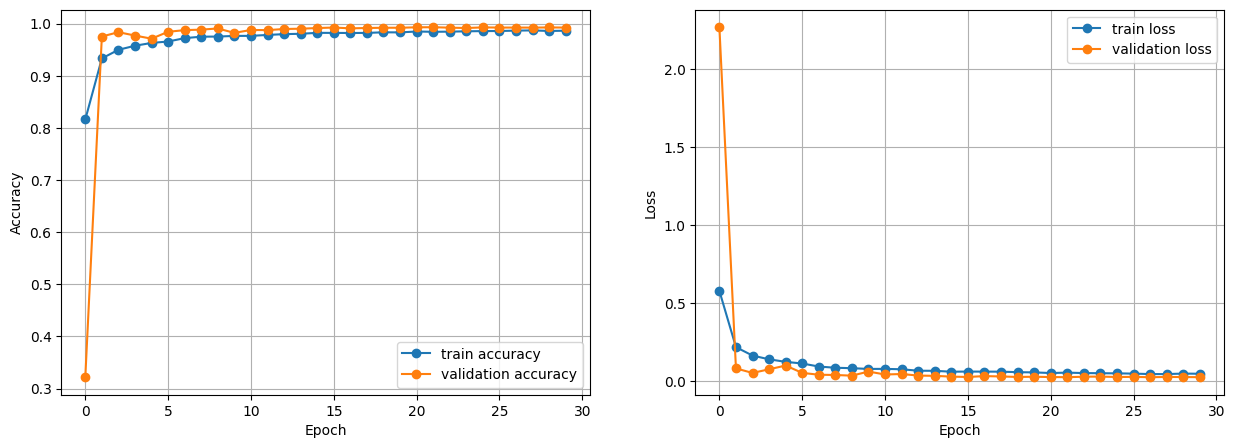

In [ ]:
if h is not None:
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], 'o-', label='train accuracy')
    plt.plot(h.history['val_accuracy'], 'o-', label='validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend(loc='lower right')
    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], 'o-', label='train loss')
    plt.plot(h.history['val_loss'], 'o-', label='validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()
else:
    print("ℹ️ No training history (model was loaded from disk)")

In [ ]:
test_loss, test_acc = model_cnn.evaluate(x_test_normalized, y_test)
print('\nTest accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9924 - loss: 0.0251

Test accuracy: 0.9923999905586243


In [ ]:
predictions = model_cnn.predict(x_test_normalized)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


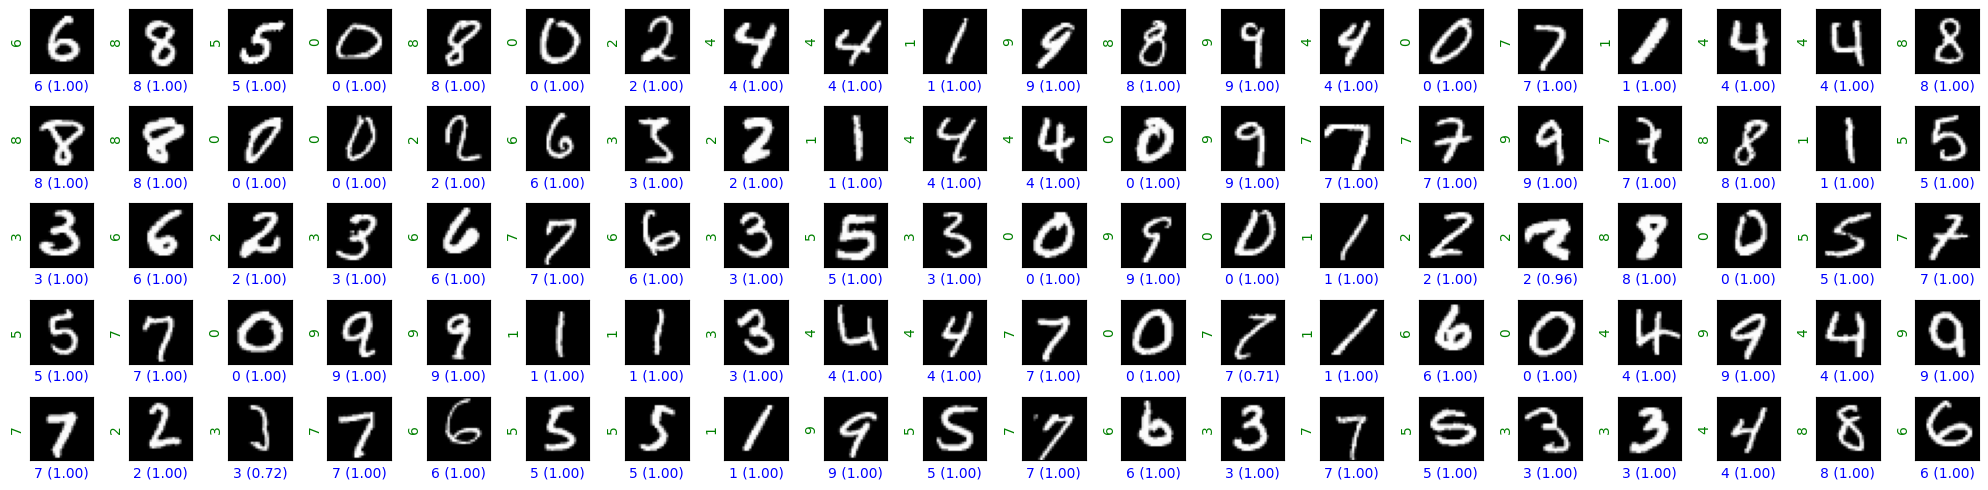

In [ ]:
ROWS = 5
COLS = 20

random_indices = random.sample(range(x_test_normalized.shape[0]), ROWS*COLS)
sample_images = x_test_normalized[random_indices, :]
sample_labels = y_test[random_indices]
predictions = model_cnn.predict(sample_images)

i = 0

plt.figure(figsize=(20,5))
for r in range(ROWS):
    for c in range(COLS):
        plt.subplot(ROWS, COLS, i+1)
        plt.imshow(sample_images[i].reshape(28,28), cmap=plt.cm.gray)
        plt.xticks([])
        plt.yticks([])
        prediction = np.argmax(predictions[i])
        confidence = predictions[i][prediction]
        if sample_labels[i] == prediction:
            plt.xlabel(f"{prediction} ({confidence:.2f})", color='b')
        else:
            plt.xlabel(f"{prediction} ({confidence:.2f})", color='r')
        plt.ylabel(sample_labels[i], color='g')
        i += 1

plt.tight_layout()
plt.show()